In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cwmeda as m
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("Data/data.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df['Alley'].value_counts(dropna=False)

Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [4]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Data exploration -EDA 

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
missing = df.isnull().sum()

In [7]:
cols = df.columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64'])
cat_cols = df.select_dtypes(include=['object'])

# only col names i want
#  DataFrame Into Sequence
cat_cols = cat_cols.columns.to_list()
num_cols = num_cols.columns.to_list()


In [8]:
print(df[cat_cols].shape)
print(df[num_cols].shape)
43+38


(1460, 43)
(1460, 38)


81

In [9]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


⚠️ Too many columns! Showing first 100 only.


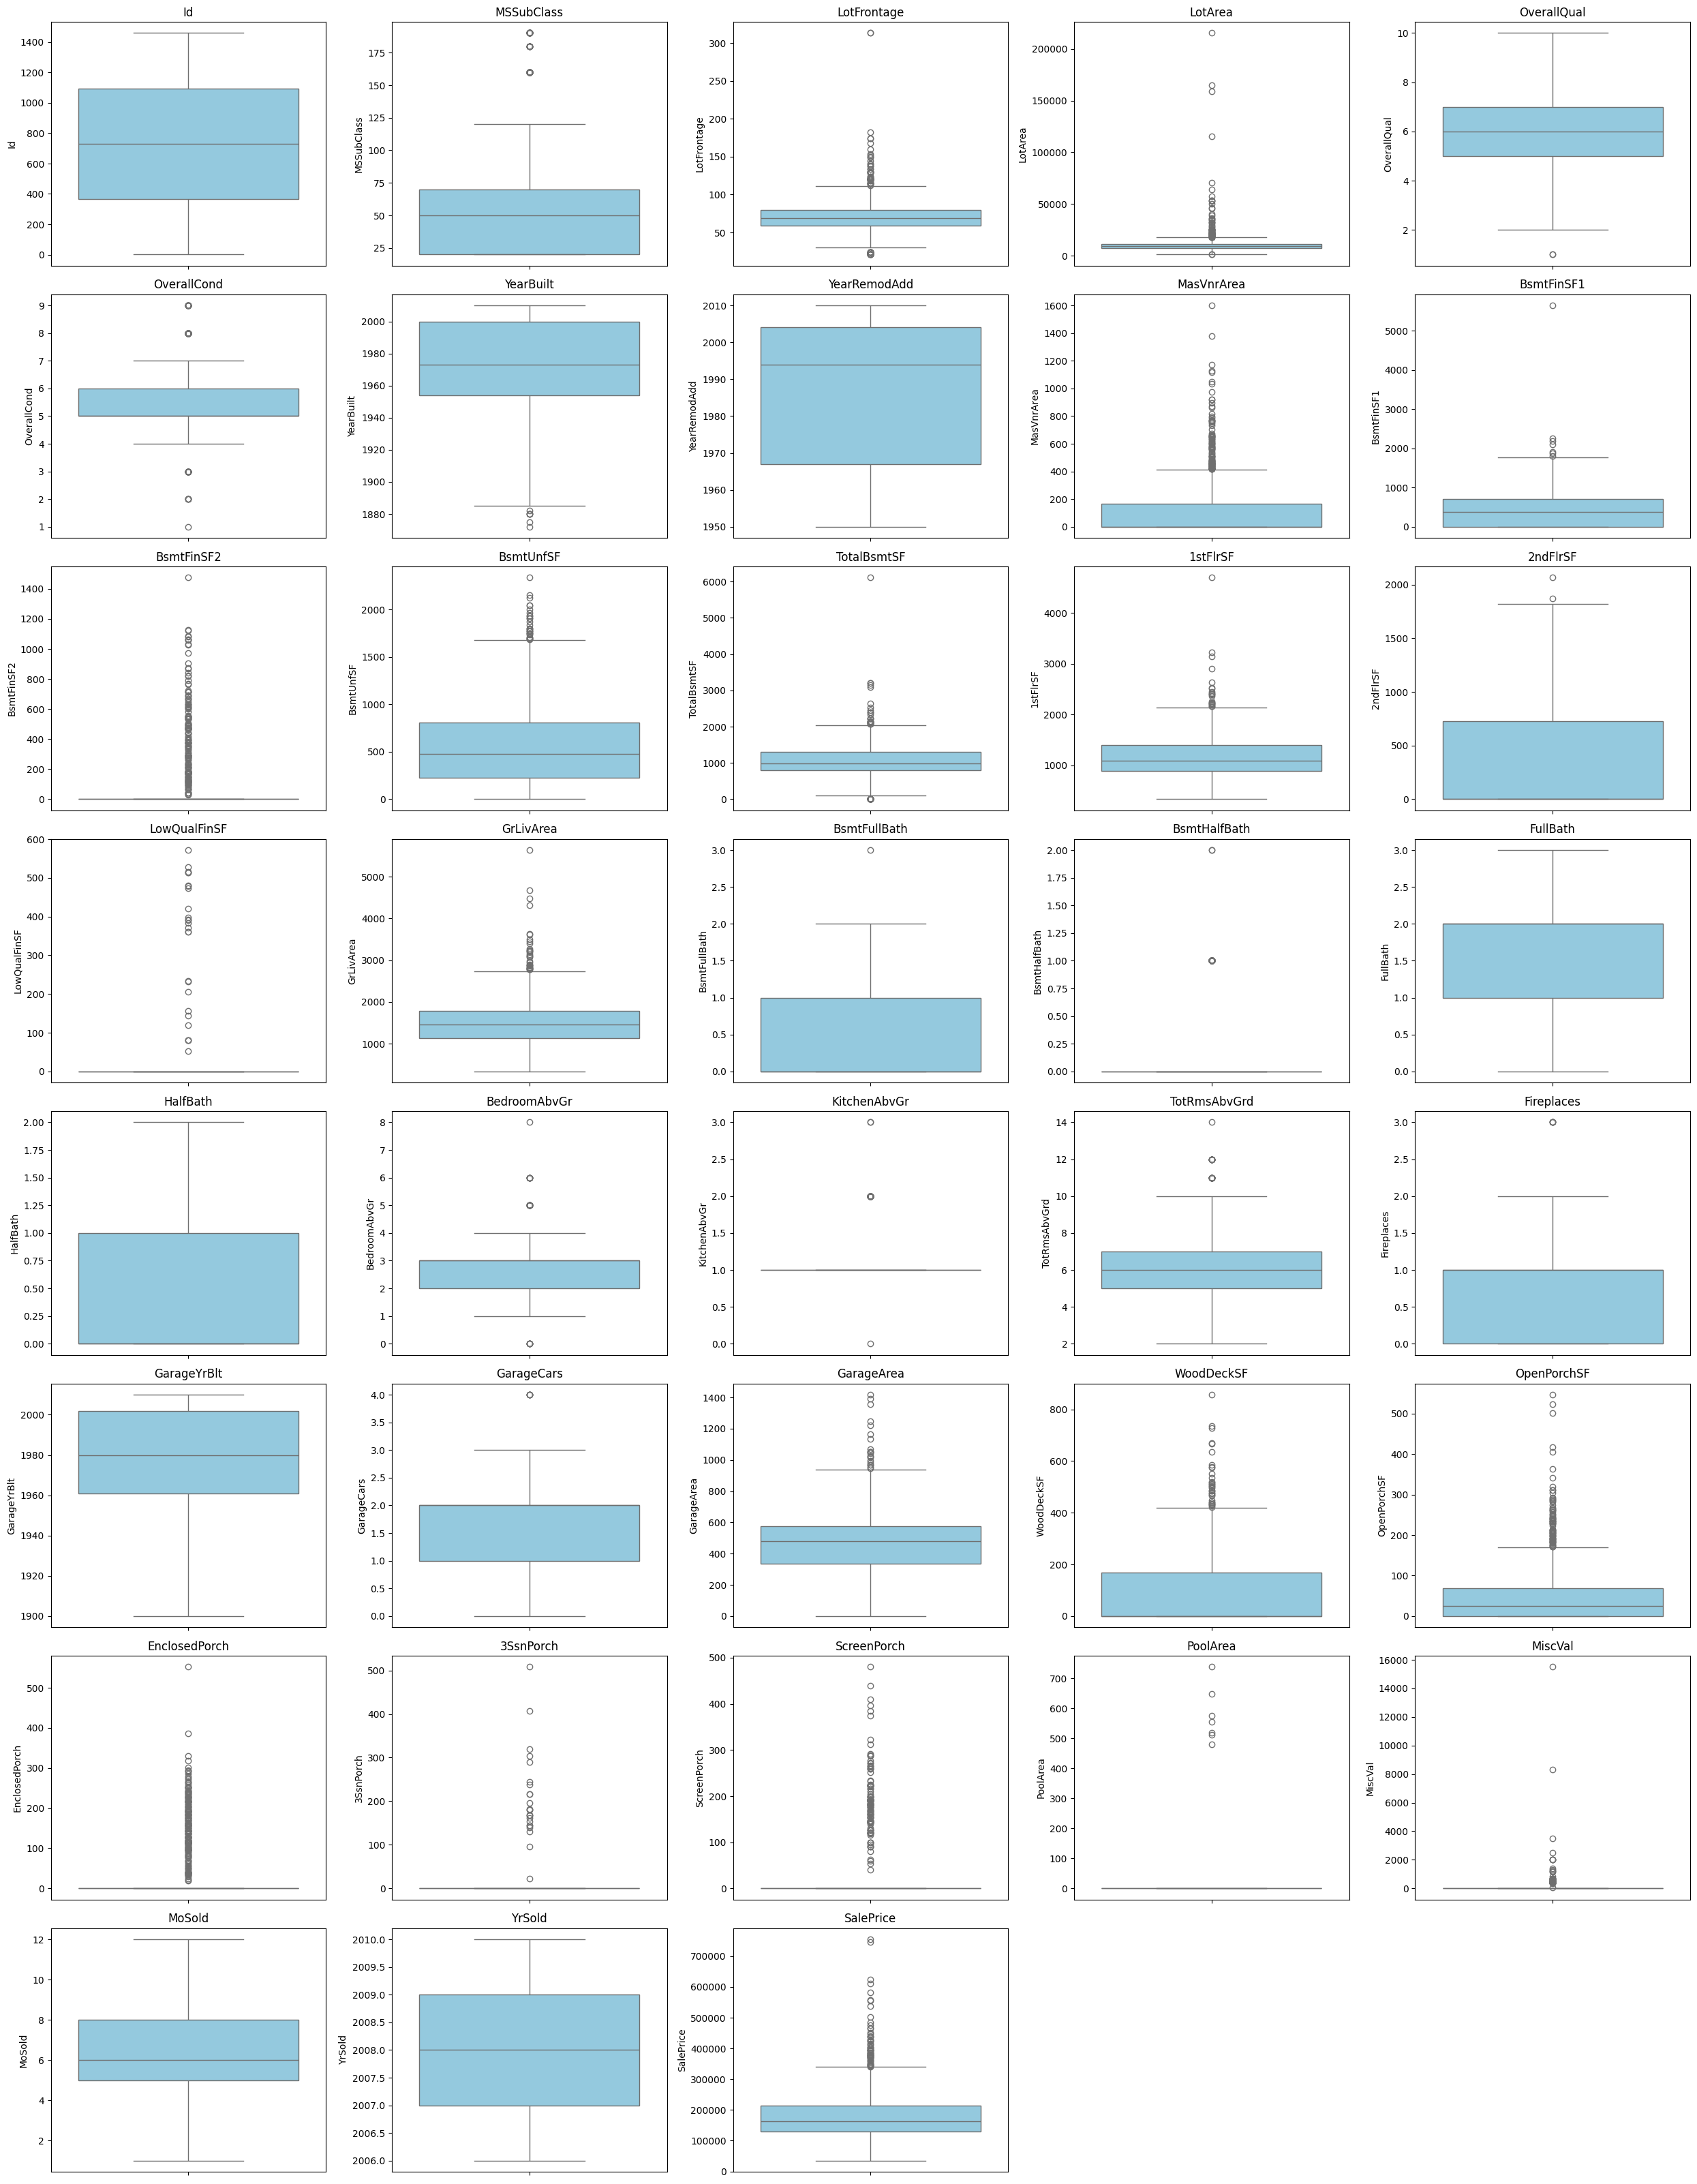

In [10]:
m.plot_columns(df,df[num_cols],plot_type='box',n_cols=5,theme='skyblue')

### I’m not only a Data Scientist but also an AI Tools Developer, specializing in Python. Currently, I’m  building my own Python library designed to help data scientists streamline their workflows and work more efficiently.

###  During this project, I developed a custom function that I plan to include in my library. My goal is to promote smart, efficient coding with minimal effort. While I leverage AI tools to assist in development, I’m careful to ensure that no sensitive or proprietary company data is ever shared. My intent is to create tools that reduce data scientists’ dependency on external AI systems for repetitive analytical tasks.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

def handle_outliers(
    df,
    cols=None,
    method="auto",
    threshold=1.5,
    visualize=True,
    n_col=3,
    random_state=42,
    verbose=True,
    force_include=None,
    skip=None
):
    """
    Smart Outlier Handler v3.1 (Offline Version)
    --------------------------------------------
    - Everything from v3
    - Added `skip` parameter to exclude target or unwanted columns
    """

    # # 1️⃣ Backup
    # bkp = df.copy()

    # 2️⃣ Select columns
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns.tolist()
    elif isinstance(cols, str):
        cols = [cols]

    # Convert skip and force_include to lists if needed
    if skip is None:
        skip = []
    elif isinstance(skip, str):
        skip = [skip]

    if force_include is None:
        force_include = []
    elif isinstance(force_include, str):
        force_include = [force_include]

    # 3️⃣ Identify skipped columns
    skip_cols = []
    reasons = {}

    for c in cols:
        if c in skip:
            skip_cols.append(c)
            reasons[c] = "Skipped manually by user (e.g., target variable)."
            continue

        if c in force_include:
            continue
        if "id" in c.lower():
            skip_cols.append(c)
            reasons[c] = "Identifier column — unique values not useful for outlier detection."
        elif df[c].nunique() < 10:
            skip_cols.append(c)
            reasons[c] = f"Categorical/ordinal variable with {df[c].nunique()} unique values."
        elif df[c].isnull().all():
            skip_cols.append(c)
            reasons[c] = "Column contains only missing values."
        elif df[c].std() == 0:
            skip_cols.append(c)
            reasons[c] = "Constant column — all values are same."
        elif df[c].std() < 1e-6:
            skip_cols.append(c)
            reasons[c] = "Very low variance — not meaningful for outlier detection."

    proc_cols = [c for c in cols if c not in skip_cols or c in force_include]

    # 4️⃣ Print skipped columns + reasoning
    if verbose:
        print(f"📦 Backup created as variable 'bkp'")
        print(f"🧮 Processing {len(proc_cols)} columns (Skipped {len(skip_cols)})\n")

        if skip_cols:
            print("⛔ Skipped Columns (Offline Insights):")
            for c in skip_cols:
                print(f"   • {c}: {reasons[c]}")
            print()

        if force_include:
            print(f"✅ Force-included columns: {force_include}\n")

    
    # 5️⃣ IsolationForest mode
    if method == "isolation":
        if verbose:
            print("🌲 Using IsolationForest for multivariate outlier detection...\n")
        iso = IsolationForest(contamination=0.02, random_state=random_state)
        preds = iso.fit_predict(df[proc_cols])
        df = df[preds == 1]
        if verbose:
            print(f"✅ Removed {(preds == -1).sum()} multivariate outliers. New shape: {df.shape}")
        return df

    # 6️⃣ Process each column
    viz_data = {}
    for col in proc_cols:
        if df[col].nunique() <= 1 or df[col].isnull().all():
            continue

        col_before = df[col].copy()
        skew_val = df[col].skew()
        adj_threshold = 3 if abs(skew_val) > 1 else threshold

        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower = Q1 - adj_threshold * IQR
        upper = Q3 + adj_threshold * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_percent = outliers / len(df) * 100

        # auto-decide method
        if method == "auto":
            if len(df) < 10000 or outlier_percent > 10:
                mode_used = "cap"
            else:
                mode_used = "remove"
        else:
            mode_used = method

        if verbose:
            print(f"\n📊 Column: {col}")
            print(f"   Skew: {skew_val:.2f}, Outliers: {outliers} ({outlier_percent:.2f}%)")
            print(f"   Method used: {mode_used.upper()}, Threshold: {adj_threshold}")

        # Apply handling
        if mode_used == "remove":
            df = df[(df[col] >= lower) & (df[col] <= upper)]
        elif mode_used == "cap":
            df[col] = np.where(df[col] < lower, lower,
                               np.where(df[col] > upper, upper, df[col]))

        if visualize:
            viz_data[col] = (col_before, df[col].copy())

    # 7️⃣ Combined visualization
    if visualize and viz_data:
        n = len(viz_data)
        n_rows = int(np.ceil(n / n_col))
        fig, axes = plt.subplots(n_rows, n_col, figsize=(5*n_col, 4*n_rows))
        axes = axes.flatten()
        i = 0
        for col, (before, after) in viz_data.items():
            data = pd.DataFrame({'Before': before, 'After': after})
            sns.boxplot(data=data, ax=axes[i])
            axes[i].set_title(col)
            i += 1
        for j in range(i, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.suptitle("📊 Before vs After Outlier Handling", fontsize=16, y=1.02)
        plt.show()

    if verbose:
        print("\n✅ Outlier handling complete!")
        print(f"Final dataset shape: {df.shape}")

    return df


In [12]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])
#  convert it back using - np.expm1()

⚠️ Too many columns! Showing first 100 only.


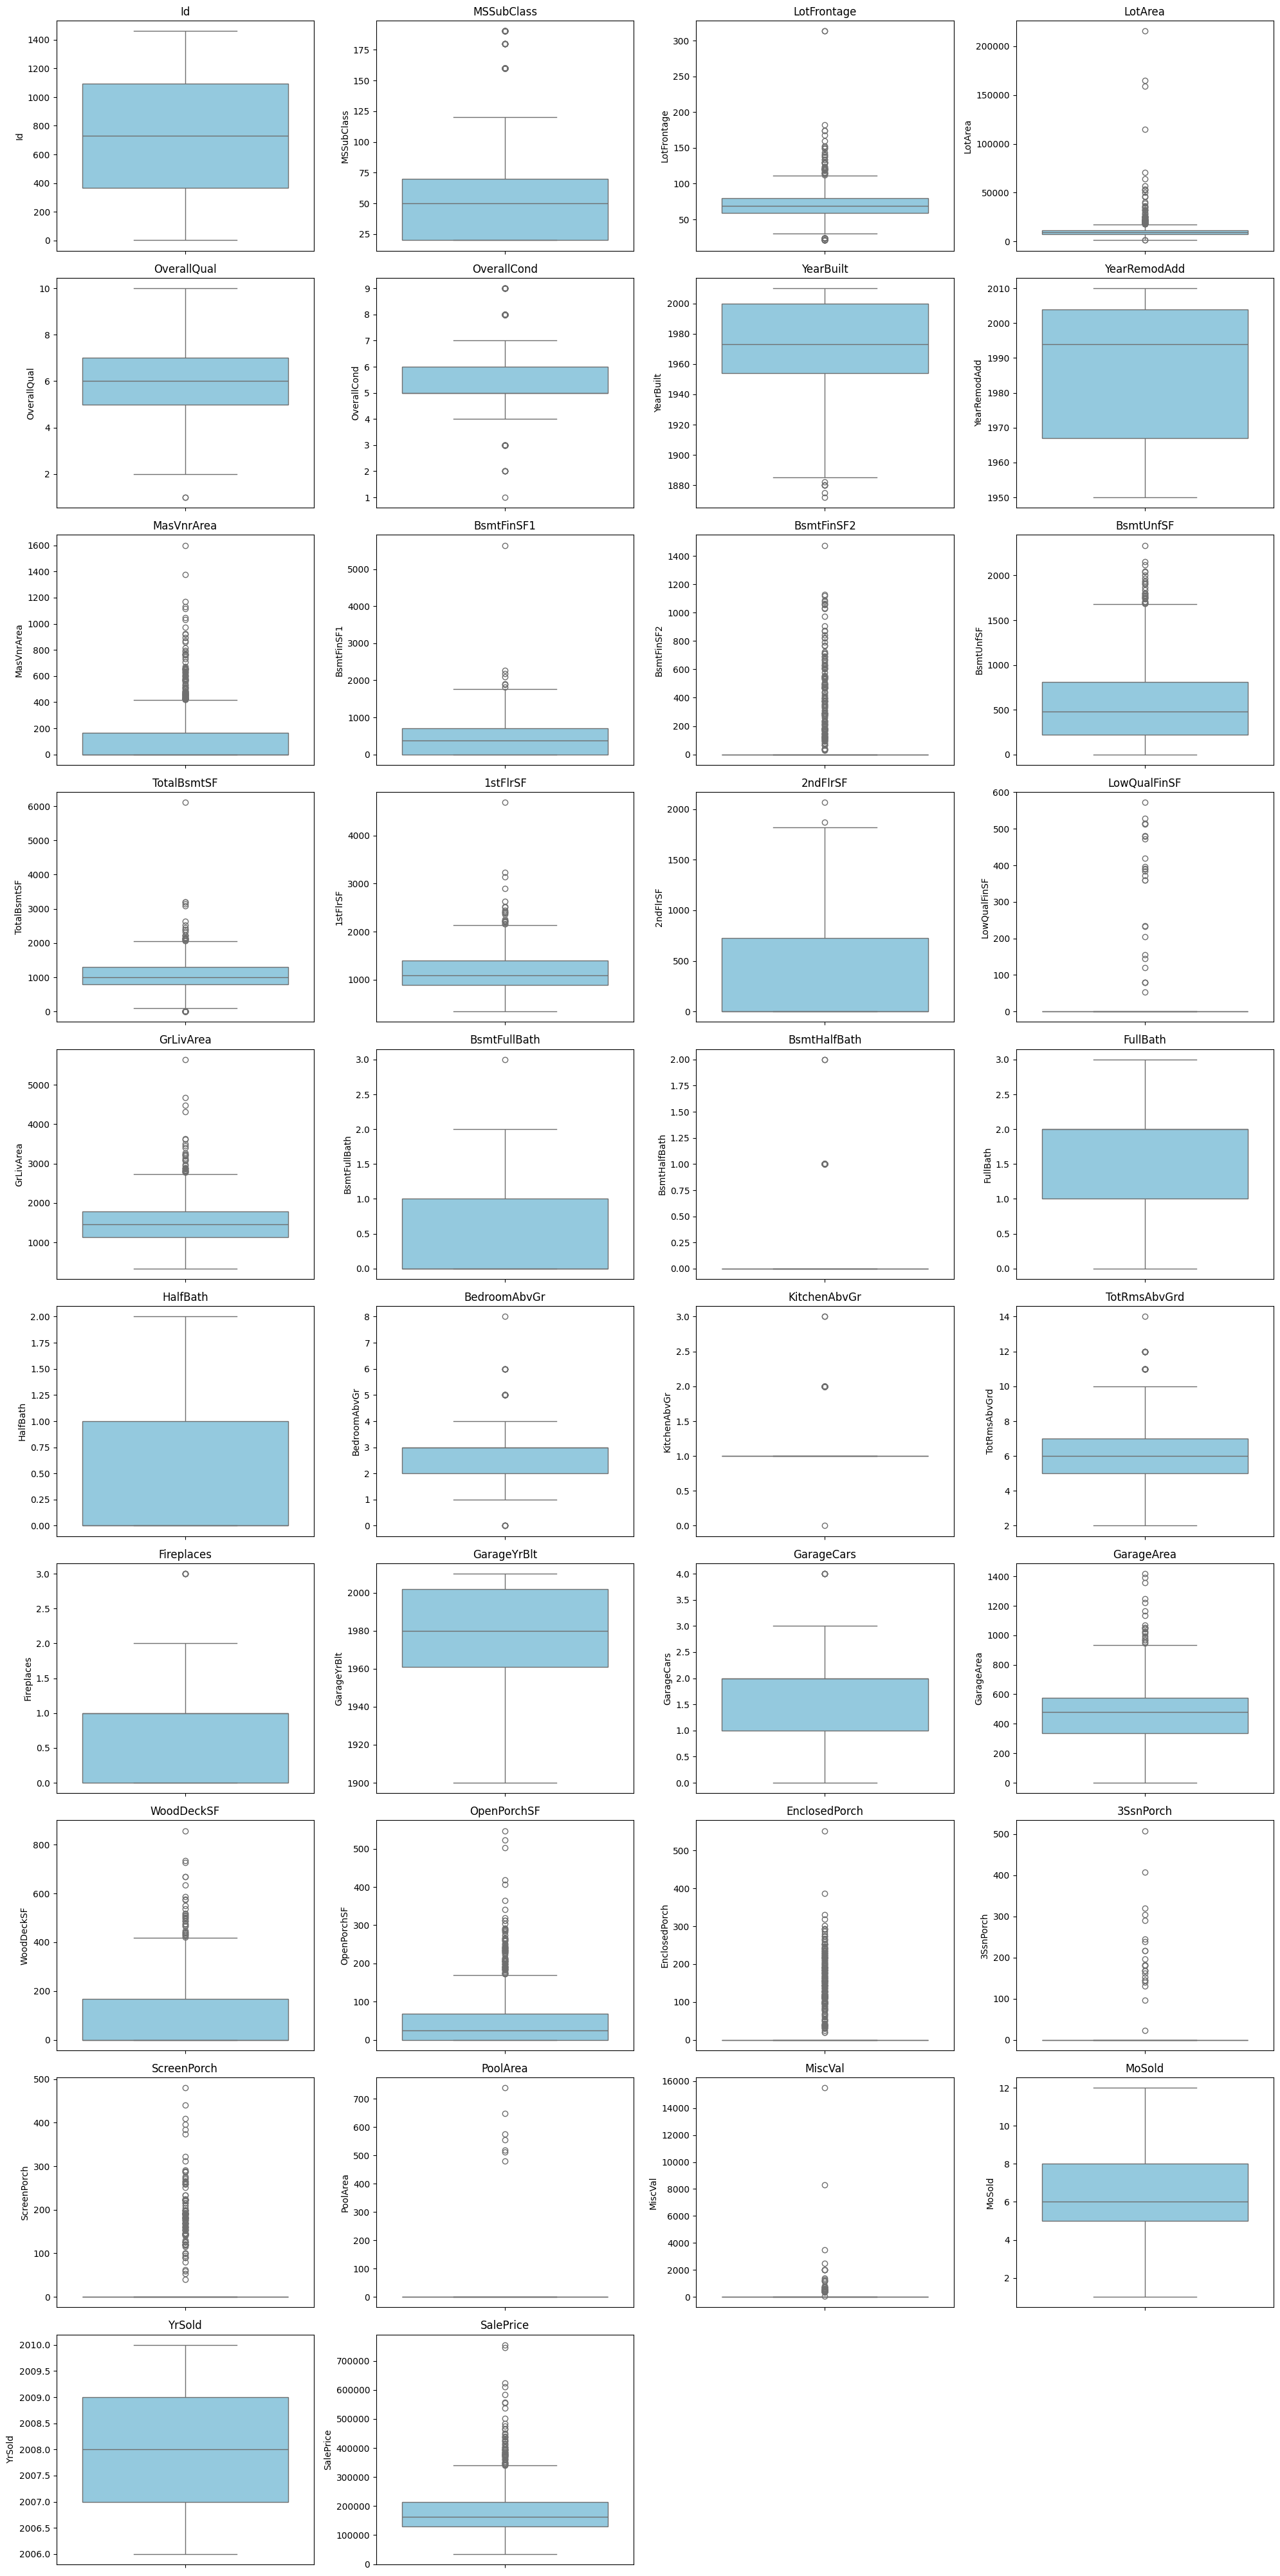

In [13]:
m.plot_columns(df,df[num_cols],plot_type='box',n_cols=4,theme='skyblue')


# Missing Values

In [14]:
import pandas as pd
def missing_value_summary(df):
    """
    Detects missing values in the DataFrame and gives recommendations.
    
    Returns a DataFrame with:
    - Column Name
    - Data Type
    - Missing Count
    - % Missing
    - Recommended Action
    """
    # Missing count
    missing_count = df.isnull().sum()
    missing_count = missing_count[missing_count > 0].sort_values(ascending=False)
    
    # Data type
    dtype = df.dtypes[missing_count.index]
    
    # Missing percentage
    missing_percent = (missing_count / len(df)) * 100
    
    # Recommended action (basic rules for Ames dataset)
    action = []
    for col in missing_count.index:
        if missing_percent[col] > 50:
            # High missing → categorical features: fill with 'None'
            if df[col].dtype == 'object':
                action.append('Fill with "None" (absence meaningful)')
            else:
                action.append('Consider dropping or fill with 0')
        elif 5 < missing_percent[col] <= 50:
            # Medium missing
            if df[col].dtype == 'object':
                action.append('Fill with "None" or mode')
            else:
                action.append('Fill with median')
        else:
            # Low missing
            if df[col].dtype == 'object':
                action.append('Fill with mode')
            else:
                action.append('Fill with median')
    
    # Combine into DataFrame
    missing_df = pd.DataFrame({
        'Column': missing_count.index,
        'Data Type': dtype.values,
        'Missing Count': missing_count.values,
        'Missing %': missing_percent.values,
        'Recommended Action': action
    })
    
    return missing_df
          
# Example usage:
# show_missing_columns(df)


In [15]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("missing cols : " , missing.shape[0])



missing cols :  19


In [16]:
missing_perc =( missing / len(df)) * 100
missing_perc


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [17]:
df.isin(["UNKNOWN"]).any(axis=1).sum()
# df.isin(["unknown"])
# df.isin(["Unknown"])

np.int64(0)

In [18]:
md = missing_value_summary(df)
md

,Column,Data Type,Missing Count,Missing %,Recommended Action
0,PoolQC,object,1453,99.520548,"Fill with ""None"" (absence meaningful)"
1,MiscFeature,object,1406,96.301370,"Fill with ""None"" (absence meaningful)"
2,Alley,object,1369,93.767123,"Fill with ""None"" (absence meaningful)"
3,Fence,object,1179,80.753425,"Fill with ""None"" (absence meaningful)"
4,MasVnrType,object,872,59.726027,"Fill with ""None"" (absence meaningful)"
5,FireplaceQu,object,690,47.260274,"Fill with ""None"" or mode"
6,LotFrontage,float64,259,17.739726,Fill with median
7,GarageType,object,81,5.547945,"Fill with ""None"" or mode"
8,GarageYrBlt,float64,81,5.547945,Fill with median
9,GarageFinish,object,81,5.547945,"Fill with ""None"" or mode"


### Dropping >80% missing columns

In [19]:
df.drop(['Fence','Alley','MiscFeature','PoolQC'],axis=1,inplace=True)
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD

In [20]:
md = missing_value_summary(df)
md

,Column,Data Type,Missing Count,Missing %,Recommended Action
0,MasVnrType,object,872,59.726027,"Fill with ""None"" (absence meaningful)"
1,FireplaceQu,object,690,47.260274,"Fill with ""None"" or mode"
2,LotFrontage,float64,259,17.739726,Fill with median
3,GarageYrBlt,float64,81,5.547945,Fill with median
4,GarageFinish,object,81,5.547945,"Fill with ""None"" or mode"
5,GarageType,object,81,5.547945,"Fill with ""None"" or mode"
6,GarageQual,object,81,5.547945,"Fill with ""None"" or mode"
7,GarageCond,object,81,5.547945,"Fill with ""None"" or mode"
8,BsmtExposure,object,38,2.602740,Fill with mode
9,BsmtFinType2,object,38,2.602740,Fill with mode


In [21]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [22]:
df.fillna({
    'MasVnrType':'None',
    'GarageCond':'None',
    'GarageQual':'None',
    'GarageType':'None',
    'GarageFinish':'None',
    'FireplaceQu':'None'
}, inplace=True)


In [23]:
md = missing_value_summary(df)
md

,Column,Data Type,Missing Count,Missing %,Recommended Action
0,LotFrontage,float64,259,17.739726,Fill with median
1,GarageYrBlt,float64,81,5.547945,Fill with median
2,BsmtExposure,object,38,2.602740,Fill with mode
3,BsmtFinType2,object,38,2.602740,Fill with mode
4,BsmtQual,object,37,2.534247,Fill with mode
5,BsmtFinType1,object,37,2.534247,Fill with mode
6,BsmtCond,object,37,2.534247,Fill with mode
7,MasVnrArea,float64,8,0.547945,Fill with median
8,Electrical,object,1,0.068493,Fill with mode


In [24]:

df.fillna({
    'LotFrontage':df['LotFrontage'].median(),
    'GarageYrBlt':df['GarageYrBlt'].median(),
    'MasVnrArea':df['MasVnrArea'].median(),

    'BsmtExposure':df['MasVnrArea'].mean(),
    'BsmtFinType2':df['MasVnrArea'].mean(),
    'BsmtQual':df['MasVnrArea'].mean(),
    'BsmtFinType1':df['MasVnrArea'].mean(),
    'BsmtCond': df['MasVnrArea'].mean(),
    'Electrical':df['MasVnrArea'].mean()
}, inplace=True)


In [25]:
md = missing_value_summary(df)
md

,Column,Data Type,Missing Count,Missing %,Recommended Action


In [26]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

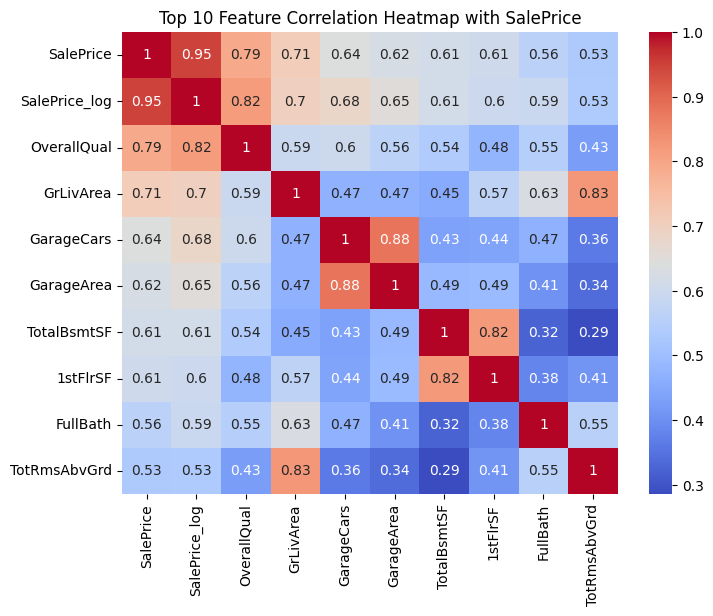

In [27]:
corr_target = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

top_corr_features = corr_target.head(10).index

plt.figure(figsize=(8, 6))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top 10 Feature Correlation Heatmap with SalePrice")
plt.show()

# Feature Engineering

### Create New Numeric Features

In [28]:
# adding New Feature
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['ReModelAge'] = df['YrSold'] - df['YearRemodAdd']

df['TotalBath'] = ( df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'] )


# total square footage
df['TotalSF'] = df['2ndFlrSF'] + df['1stFlrSF'] + df['TotalBsmtSF']

### Log Transform Skewed Features

In [29]:
# Transform target variable
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Example: GrLivArea
df['GrLivArea_log'] = np.log1p(df['GrLivArea'])

In [30]:
df.to_csv("Before Encoding.csv")


### Encoding Categorical column

#### in the data 2 types of categorical columns
#### nominal --> categories with natural numbers
#### ordinal --> categories with ordered numbers

In [31]:
l1_ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond',
    # 'PoolQC' removed
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'Functional', 'PavedDrive'
]


l2_nominal_cols = [
    'MSSubClass',      # Type of dwelling (can also be treated as categorical)
    'MSZoning',        # Zoning classification
    'Street',          # Road type
    # 'Alley',           # Alley type
    'LotShape',        # Property shape
    'LandContour',     # Land flatness
    'Utilities',       # Utilities available
    'LotConfig',       # Lot configuration
    'LandSlope',       # Land slope
    'Neighborhood',    # Physical location
    'Condition1',      # Proximity to main road
    'Condition2',      # Second proximity
    'BldgType',        # Type of dwelling
    'HouseStyle',      # Style of house
    'RoofStyle',       # Type of roof
    'RoofMatl',        # Roof material
    'Exterior1st',     # Exterior material
    'Exterior2nd',     # Second exterior material
    'MasVnrType',      # Masonry type
    'Foundation',      # Type of foundation
    'Heating',         # Type of heating
    'CentralAir',      # Central air conditioning (Y/N → can also map to 1/0)
    'Electrical',      # Electrical system
    'GarageType',      # Garage location
    'GarageFinish',    # Garage interior finish
    # 'Fence',           # Fence quality
    # 'MiscFeature',     # Miscellaneous feature
    'MoSold',          # Month Sold (can be treated as categorical)
    'SaleType',        # Type of sale
    'SaleCondition'    # Sale condition
]


In [32]:
# Manual ordinal mappings based on quality, condition, and levels
quality_map     = {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5}
exposure_map    = {'None':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4}
fin_type_map    = {'None':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6}
functional_map  = {'Sev':1, 'Maj2':2, 'Maj1':3, 'Mod':4, 'Min2':5, 'Min1':6, 'Typ':7}
paved_drive_map = {'N':0, 'P':1, 'Y':2}

# Apply mappings to corresponding columns
ordinal_mappings = {
    'ExterQual': quality_map,
    'ExterCond': quality_map,
    'BsmtQual': quality_map,
    'BsmtCond': quality_map,
    'HeatingQC': quality_map,
    'KitchenQual': quality_map,
    'FireplaceQu': quality_map,
    'GarageQual': quality_map,
    'GarageCond': quality_map,
    'PoolQC': quality_map,
    'BsmtExposure': exposure_map,
    'BsmtFinType1': fin_type_map,
    'BsmtFinType2': fin_type_map,
    'Functional': functional_map,
    'PavedDrive': paved_drive_map
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)


In [33]:
df[l1_ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Functional,PavedDrive
0,4,3,4.0,3.0,5,4,0,3,3,1.0,6.0,1.0,7,2
1,3,3,4.0,3.0,5,3,3,3,3,4.0,5.0,1.0,7,2
2,4,3,4.0,3.0,5,4,3,3,3,2.0,6.0,1.0,7,2
3,3,3,3.0,4.0,4,4,4,3,3,1.0,5.0,1.0,7,2
4,4,3,4.0,3.0,5,4,3,3,3,3.0,6.0,1.0,7,2


In [34]:
df.isnull().sum()
df.dropna(inplace=True)


In [35]:
df[l2_nominal_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1421 entries, 0 to 1459
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1421 non-null   int64 
 1   MSZoning       1421 non-null   object
 2   Street         1421 non-null   object
 3   LotShape       1421 non-null   object
 4   LandContour    1421 non-null   object
 5   Utilities      1421 non-null   object
 6   LotConfig      1421 non-null   object
 7   LandSlope      1421 non-null   object
 8   Neighborhood   1421 non-null   object
 9   Condition1     1421 non-null   object
 10  Condition2     1421 non-null   object
 11  BldgType       1421 non-null   object
 12  HouseStyle     1421 non-null   object
 13  RoofStyle      1421 non-null   object
 14  RoofMatl       1421 non-null   object
 15  Exterior1st    1421 non-null   object
 16  Exterior2nd    1421 non-null   object
 17  MasVnrType     1421 non-null   object
 18  Foundation     1421 non-null   ob

In [36]:
df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)


In [37]:
for col in l2_nominal_cols:
    if col in df.columns:
        unique_types = df[col].dropna().map(type).unique()
        if len(unique_types) > 1:
            print(f"Mixed types in column: {col} → {unique_types}")


Mixed types in column: Electrical → [<class 'str'> <class 'float'>]


In [38]:
# fixing mixed column 
print(df['Electrical'].unique())
df['Electrical'] = df['Electrical'].astype(str)


['SBrkr' 'FuseF' 'FuseA' 'FuseP' 'Mix' 103.68526170798899]


# Encoding

In [39]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform
encoded_data = encoder.fit_transform(df[l2_nominal_cols])

# Create DataFrame of encoded columns
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(l2_nominal_cols),
    index=df.index
)

# Drop original nominal columns and merge back
df.drop(l2_nominal_cols, axis=1, inplace=True)
df = pd.concat([df, encoded_df], axis=1)

print("Nominal Encoding Done!")
print("New shape:", df.shape)


Nominal Encoding Done!
New shape: (1421, 254)


In [40]:
from sklearn.model_selection import train_test_split as tts 
# separation of featues and target
X = df.drop(['SalePrice', 'SalePrice_log'], axis=1, errors='ignore')
y = df['SalePrice_log'] if 'SalePrice_log' in df.columns else df['SalePrice']

# X.isnull().sum()
# split First
X_train, X_test, y_train, y_test = tts(X,y,test_size=0.2,random_state=42)

### scalling for features columns

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#  fit and transform data 
X_train_Scaled  = scaler.fit_transform(X_train)  # train and test
X_test_Scaled  = scaler.transform(X_test)  # test only

# LinearRegression Model

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error as mse, root_mean_squared_error as rmse

LR_model = LinearRegression()

LR_model.fit(X_train_Scaled,y_train)

y_predicted = LR_model.predict(X_test_Scaled)

# print(r2_score)
print("RMSE: ",rmse(y_test,y_predicted))
print("MSE: ",mse(y_test,y_predicted))
print("R2: ",r2_score(y_test,y_predicted))

RMSE:  0.11354938472499822
MSE:  0.012893462771425659
R2:  0.9094095672349136


#### My Linear Regression model achieved an R² of 0.91 and RMSE of 0.11, showing strong predictive performance for the Ames Housing dataset.

# Visualization of Linear Regression Model

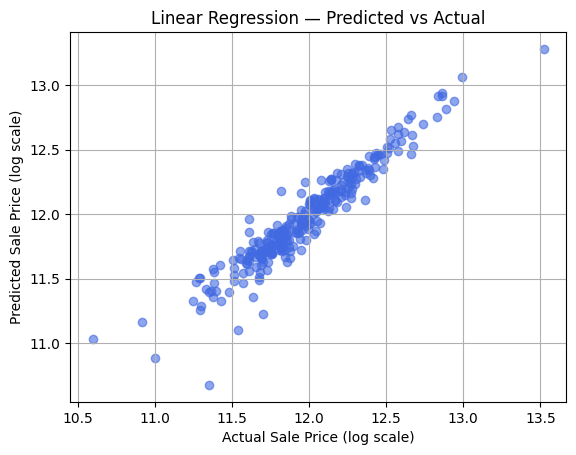

In [43]:
# actual vs predicted 

import matplotlib.pyplot as plt
plt.scatter (y_test,y_predicted, alpha=0.6, color='royalblue')
plt.xlabel("Actual Sale Price (log scale)")
plt.ylabel("Predicted Sale Price (log scale)")
plt.title("Linear Regression — Predicted vs Actual")
plt.grid(True)
plt.show()

# Ridge Regression

In [44]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)

# Higher alpha → stronger penalty → simpler model

# Lower alpha → behaves more like normal Linear Regression

ridge.fit(X_train_Scaled, y_train)
print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [45]:
y_pred_ridge = ridge.predict(X_test_Scaled)

print("RMSE: ", rmse(y_test,y_pred_ridge))
print("R2-score: ", r2_score(y_test,y_pred_ridge))

RMSE:  0.11341774333317987
R2-score:  0.9096194941826904


# Lasso Regression

In [46]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001,random_state=40)

# Higher alpha → stronger penalty → simpler model

# Lower alpha → behaves more like normal Linear Regression

lasso.fit(X_train_Scaled, y_train)
print("lasso Regression model trained successfully!")

lasso Regression model trained successfully!


In [47]:
y_pred_lasso = lasso.predict(X_test_Scaled)

print("RMSE: ", rmse(y_test,y_pred_ridge))
print("R2-score: ", r2_score(y_test,y_pred_ridge))

RMSE:  0.11341774333317987
R2-score:  0.9096194941826904


# Random Forest  - no need of scalling

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,    # number of trees (we can increase it for accuracy)
    max_depth=None,    # allow trees to grow fully
    random_state=42,
    n_jobs= 1       # use all CPU cores for speed               
                           )

In [49]:
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

# evaluation matrics
print("RMSE: ", rmse(y_test,y_pred_rf))
print("MSE: ",mse(y_test,y_pred_rf))
print("R2-score: ", r2_score(y_test,y_pred_rf))


RMSE:  0.13355654488376315
MSE:  0.017837350681288642
R2-score:  0.8746734413984062


# XGBOOST

In [50]:
from xgboost import XGBRegressor


In [51]:
xgb_model = XGBRegressor(
    n_estimators=300,        # number of boosting rounds (trees)
    learning_rate=0.05,      # smaller = slower but more accurate
    max_depth=5,             # tree depth (controls complexity)
    subsample=0.8,           # use 80% data per tree (to reduce overfitting)
    colsample_bytree=0.8,    # use 80% features per tree
    random_state=42,
    n_jobs=-1
)

In [52]:
xgb_model.fit(X_train,y_train)
y_pred_xg = xgb_model.predict(X_test)

# evaluation matrics
print("RMSE: ", rmse(y_test,y_pred_xg))
print("MSE: ",mse(y_test,y_pred_xg))
print("R2-score: ", r2_score(y_test,y_pred_xg))

RMSE:  0.1239769587627256
MSE:  0.015370286304054565
R2-score:  0.892007220039181


##### I chose Linear Regression because it provides a simple, interpretable baseline model that performs well on this dataset with strong linear relationships between features and house prices.

# LINEAR REGRESSION PIPELINE

In [53]:
# Create pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error as mae

model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit the model
model.fit(X_train,y_train)


# Predict
y_pred = model.predict(X_test)

# Evaluate performance

r2_score(y_test, y_pred)
mae(y_test, y_pred)
rmse(y_test, y_pred)

# evaluation matrics
print("RMSE: ", rmse(y_test,y_pred))
print("MAE: ",mae(y_test,y_pred))
print("R2-score: ", r2_score(y_test,y_pred))


RMSE:  0.11354938472499822
MAE:  0.0789804494470196
R2-score:  0.9094095672349136


In [54]:
import joblib

joblib.dump(model,'linear_regression_pipeline.pkl' )
print("Model pipeline saved successfully!")

Model pipeline saved successfully!


#### linear_regression_pipeline.pkl → Contains the full machine learning pipeline (with encoding, scaling, and feature transformations). Used for internal evaluation and model comparison.

#### **model.pkl** → A simplified version trained on a few key numeric features.This file is used in the **Django web app** for easy user input and real-time prediction.

In [55]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib



# Use only simple numeric columns
features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt"]
X = df[features]
y = df["SalePrice"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Save the trained model
joblib.dump(model, "model.pkl")
print("✅ Model trained and saved successfully!")


✅ Model trained and saved successfully!


#### During model development, I experimented with a complete feature-rich pipeline (linear_regression_pipeline.pkl) to understand data preprocessing and scaling.For deployment, I created a simplified model (model.pkl) with six essential numeric features to make the web app user-friendly and efficient.